# Five-Trading-Day Exponentially Weighted Z-Score Backtest

This notebook is a standalone strategy variant. It does **not** modify or
call the repository's strategy engine. The signal specification is:

- trailing z-score window: **5 observed UTC trading dates**;
- exponential weight half-life: **1 calendar day**;
- z-score history resets whenever the `(CL contract, BZ contract)` pair changes;
- z-scores become available after **30 valid observations** following a reset;
- no ADF or KPSS stationarity gate;
- entry at `z <= -2` (long) or `z >= 2` (short);
- AR(1) half-life estimated from the latest 30 consecutive one-minute observations;
- accepted half-life: `0 < half-life <= 30 minutes`;
- exit when `abs(z) <= 0.5`, or on the unchanged $100 stop, 120-minute time
  stop, or session end;
- no entries during the first three calendar days of each annual test window;
- no new entries during the final 60 minutes before the 19:59 UTC session close.

Long entries pay the listed-spread ask and liquidate at the bid. Short entries
sell the bid and cover at the ask. P&L uses a 1,000-barrel multiplier.

In [1]:
from collections import deque
from pathlib import Path
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplconfig-ewm-backtest-"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "_data" / "clean"
OUTPUT_DIR = PROJECT_ROOT / "_output" / "ewm_7d_zscore_backtest"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

Matplotlib is building the font cache; this may take a moment.


## Fixed strategy parameters

In [2]:
ZSCORE_TRADING_DAYS = 5
WEIGHT_HALFLIFE = pd.Timedelta(days=1)
ZSCORE_MIN_OBSERVATIONS = 30
ENTRY_Z = 2.0
EXIT_Z = 0.5
HALFLIFE_OBSERVATIONS = 30
MAX_HALFLIFE_MINUTES = 30.0
STOP_LOSS_USD = 100.0
TIME_STOP_MINUTES = 120
ENTRY_CUTOFF_MINUTES = 60
NO_TRADE_CALENDAR_DAYS = 3
CONTRACT_MULTIPLIER = 1_000.0

parameters = pd.Series(
    {
        "zscore_trading_days": ZSCORE_TRADING_DAYS,
        "weight_halflife": str(WEIGHT_HALFLIFE),
        "zscore_min_observations": ZSCORE_MIN_OBSERVATIONS,
        "entry_z": ENTRY_Z,
        "halflife_observations": HALFLIFE_OBSERVATIONS,
        "maximum_halflife_minutes": MAX_HALFLIFE_MINUTES,
        "exit_zscore_band": EXIT_Z,
        "stop_loss_usd": STOP_LOSS_USD,
        "time_stop_minutes": TIME_STOP_MINUTES,
        "entry_cutoff_minutes_before_session_end": ENTRY_CUTOFF_MINUTES,
        "no_trade_calendar_days_at_start": NO_TRADE_CALENDAR_DAYS,
    },
    name="value",
)
parameters

zscore_trading_days                                      5
weight_halflife                            1 days 00:00:00
zscore_min_observations                                 30
entry_z                                                2.0
halflife_observations                                   30
maximum_halflife_minutes                              30.0
exit_zscore_band                                       0.5
stop_loss_usd                                        100.0
time_stop_minutes                                      120
entry_cutoff_minutes_before_session_end                 60
no_trade_calendar_days_at_start                          3
Name: value, dtype: object

## Load three consecutive blocks per year

Source files are concatenated by year, duplicate timestamps are removed, and
each annual window is clipped to its requested three-week range. Thus the
five-trading-day signal history can carry across a file boundary. It resets
only on a CL/BZ contract-pair change, exactly as specified.

In [3]:
YEAR_FILES = {
    2023: [
        "stable_2023_brent_wti_aligned_1m_2023-05-01_2023-05-06.parquet",
        "stable_2023_brent_wti_aligned_1m_2023-05-06_2023-05-13.parquet",
        "stable_2023_brent_wti_aligned_1m_2023-05-13_2023-05-20.parquet",
    ],
    2024: [
        "brent_wti_aligned_1m_2024-05-06_2024-05-13.parquet",
        "brent_wti_aligned_1m_2024-05-13_2024-05-20.parquet",
        "brent_wti_aligned_1m_2024-05-20_2024-05-27.parquet",
    ],
    2025: [
        "brent_wti_aligned_1m_2025-04-28_2025-05-05.parquet",
        "brent_wti_aligned_1m_2025-05-05_2025-05-10.parquet",
        "brent_wti_aligned_1m_2025-05-06_2025-05-13.parquet",
        "brent_wti_aligned_1m_2025-05-13_2025-05-20.parquet",
    ],
    2026: [
        "brent_wti_aligned_1m_2026-06-01_2026-06-06.parquet",
        "brent_wti_aligned_1m_2026-06-06_2026-06-13.parquet",
        "brent_wti_aligned_1m_2026-06-13_2026-06-20.parquet",
    ],
}

YEAR_RANGES = {
    2023: ("2023-05-01", "2023-05-20"),
    2024: ("2024-05-06", "2024-05-27"),
    2025: ("2025-04-28", "2025-05-19"),
    2026: ("2026-06-01", "2026-06-20"),
}


def load_year(paths: list[str], start: str, end: str) -> pd.DataFrame:
    missing = [name for name in paths if not (DATA_DIR / name).exists()]
    if missing:
        raise FileNotFoundError(f"Missing aligned data files: {missing}")
    frames = [pd.read_parquet(DATA_DIR / name) for name in paths]
    data = pd.concat(frames).sort_index()
    data = data.loc[~data.index.duplicated(keep="last")]
    start_utc = pd.Timestamp(start, tz="UTC")
    end_utc = pd.Timestamp(end, tz="UTC")
    data = data.loc[(data.index >= start_utc) & (data.index < end_utc)]
    return data.between_time("00:00", "19:59")


year_data = {
    year: load_year(files, *YEAR_RANGES[year])
    for year, files in YEAR_FILES.items()
}

data_inventory = pd.DataFrame(
    [
        {
            "year": year,
            "rows": len(data),
            "start_utc": data.index.min(),
            "end_utc": data.index.max(),
            "contract_pairs": data[["cl_instrument_id", "bz_instrument_id"]].drop_duplicates().shape[0],
        }
        for year, data in year_data.items()
    ]
).set_index("year")
data_inventory

,rows,start_utc,end_utc,contract_pairs
year,,,,
2023,18120,2023-05-01 00:00:00+00:00,2023-05-19 19:59:00+00:00,2
2024,25200,2024-05-06 00:00:00+00:00,2024-05-26 19:59:00+00:00,3
2025,25200,2025-04-28 00:00:00+00:00,2025-05-18 19:59:00+00:00,3
2026,18781,2026-06-01 00:00:00+00:00,2026-06-19 17:00:00+00:00,3


## Signal calculations

The exponentially weighted mean and population variance use
`weight = 2 ** (-calendar age / 1 day)`. The window retains the current
observed UTC trading date and the preceding four observed trading dates.
Thus weekends and holidays do not consume lookback slots, while the unchanged
one-calendar-day weight half-life still discounts observations across gaps.

In [4]:
def estimate_halflife(values: deque[float]) -> float:
    """AR(1) half-life from exactly 30 consecutive one-minute observations."""
    if len(values) != HALFLIFE_OBSERVATIONS:
        return np.nan
    series = pd.Series(values, dtype=float)
    if series.nunique() < 3:
        return np.nan
    y = series.iloc[1:]
    x = sm.add_constant(series.shift(1).iloc[1:])
    try:
        phi = float(sm.OLS(y, x).fit().params.iloc[1])
    except Exception:
        return np.nan
    if not np.isfinite(phi) or phi <= 0 or phi >= 1:
        return np.nan
    return float(-np.log(2) / np.log(phi))


def add_weighted_zscore(data: pd.DataFrame) -> pd.DataFrame:
    """Calculate the 5-trading-day EWM z-score with contract-pair resets."""
    out = data.copy()
    zscores = np.full(len(out), np.nan)
    means = np.full(len(out), np.nan)
    stds = np.full(len(out), np.nan)
    observations = np.zeros(len(out), dtype=int)
    resets = np.zeros(len(out), dtype=bool)

    history = deque()
    trading_date_counts = {}
    weight_sum = weighted_x = weighted_x2 = 0.0
    regime_origin = None
    previous_valid_pair = None
    decay_rate = np.log(2) / WEIGHT_HALFLIFE.total_seconds()

    for i, (timestamp, row) in enumerate(out.iterrows()):
        pair = (row["cl_instrument_id"], row["bz_instrument_id"])
        valid_pair = pd.notna(pair[0]) and pd.notna(pair[1])

        # Missing/non-trading rows have (NaN, NaN) identifiers. They are not
        # contract rolls and must not replace the last observed valid pair.
        if valid_pair and (previous_valid_pair is None or pair != previous_valid_pair):
            history.clear()
            trading_date_counts.clear()
            weight_sum = weighted_x = weighted_x2 = 0.0
            regime_origin = timestamp
            resets[i] = True
            previous_valid_pair = pair

        value = row["synth_mid"]
        eligible = (
            pd.notna(value)
            and pd.notna(row["ls_bid_px_00"])
            and pd.notna(row["ls_ask_px_00"])
            and valid_pair
            and row["cl_n_events"] > 0
            and row["bz_n_events"] > 0
        )
        if not eligible:
            continue

        trading_date = timestamp.date()
        trading_date_counts[trading_date] = trading_date_counts.get(trading_date, 0) + 1

        elapsed = (timestamp - regime_origin).total_seconds()
        weight = np.exp(decay_rate * elapsed)
        value = float(value)
        history.append((timestamp, weight, value, trading_date))
        weight_sum += weight
        weighted_x += weight * value
        weighted_x2 += weight * value * value

        while len(trading_date_counts) > ZSCORE_TRADING_DAYS:
            _, old_weight, old_value, old_date = history.popleft()
            weight_sum -= old_weight
            weighted_x -= old_weight * old_value
            weighted_x2 -= old_weight * old_value * old_value
            trading_date_counts[old_date] -= 1
            if trading_date_counts[old_date] == 0:
                del trading_date_counts[old_date]
        observations[i] = len(history)

        if len(history) >= ZSCORE_MIN_OBSERVATIONS:
            mean = weighted_x / weight_sum
            variance = max(weighted_x2 / weight_sum - mean * mean, 0.0)
            std = np.sqrt(variance)
            means[i] = mean
            stds[i] = std
            if std > 1e-12:
                zscores[i] = (value - mean) / std

    out["ewm_mean_5td"] = means
    out["ewm_std_5td"] = stds
    out["zscore"] = zscores
    out["zscore_observations"] = observations
    out["regime_reset"] = resets
    return out


signal_data = {year: add_weighted_zscore(data) for year, data in year_data.items()}

for data in signal_data.values():
    assert data.loc[data["zscore_observations"] < ZSCORE_MIN_OBSERVATIONS, "zscore"].isna().all()
    invalid_pair = data[["cl_instrument_id", "bz_instrument_id"]].isna().any(axis=1)
    assert not data.loc[invalid_pair, "regime_reset"].any()
    valid_pairs = data.loc[~invalid_pair, ["cl_instrument_id", "bz_instrument_id"]]
    expected_resets = valid_pairs.ne(valid_pairs.shift()).any(axis=1).sum()
    assert int(data["regime_reset"].sum()) == int(expected_resets)

signal_diagnostics = pd.DataFrame(
    [
        {
            "year": year,
            "zscore_rows": data["zscore"].notna().sum(),
            "regime_resets": data["regime_reset"].sum(),
            "long_threshold_rows": data["zscore"].le(-ENTRY_Z).sum(),
            "short_threshold_rows": data["zscore"].ge(ENTRY_Z).sum(),
        }
        for year, data in signal_data.items()
    ]
).set_index("year")
signal_diagnostics

,zscore_rows,regime_resets,long_threshold_rows,short_threshold_rows
year,,,,
2023,17888,1,857,258
2024,17864,2,84,1503
2025,17936,2,623,307
2026,17761,2,235,509


## Standalone execution backtest

In [5]:
def run_backtest(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    tracker = pd.DataFrame(
        index=data.index,
        columns=[
            "synth_mid", "ewm_mean_5td", "zscore", "halflife", "position",
            "long_entry", "short_entry", "exit_flag", "exit_reason",
            "entry_price", "position_age", "position_pnl", "step_pnl", "cum_pnl",
        ],
    )
    trades = []
    position = 0
    entry_price = np.nan
    entry_time = None
    entry_zscore = np.nan
    entry_halflife = np.nan
    position_pnl = 0.0
    age = 0
    cumulative_pnl = 0.0
    hl_history = deque(maxlen=HALFLIFE_OBSERVATIONS)
    previous_timestamp = None
    previous_pair = None
    session_blocks = data.index.to_series().diff().ne(pd.Timedelta(minutes=1)).cumsum()
    session_closes = data.index.to_series().groupby(session_blocks).transform("max")
    first_trade_time = data.index.min().normalize() + pd.Timedelta(days=NO_TRADE_CALENDAR_DAYS)

    for i, (timestamp, row) in enumerate(data.iterrows()):
        pair = (row["cl_instrument_id"], row["bz_instrument_id"])
        consecutive = previous_timestamp is not None and timestamp - previous_timestamp == pd.Timedelta(minutes=1)
        if pair != previous_pair or not consecutive:
            hl_history.clear()
        previous_pair = pair
        previous_timestamp = timestamp

        eligible = (
            pd.notna(row["synth_mid"])
            and pd.notna(row["ls_bid_px_00"])
            and pd.notna(row["ls_ask_px_00"])
            and pd.notna(pair[0])
            and pd.notna(pair[1])
            and row["cl_n_events"] > 0
            and row["bz_n_events"] > 0
        )
        if eligible:
            hl_history.append(float(row["synth_mid"]))

        session_close = session_closes.iloc[i]
        session_end = timestamp == session_close
        entry_cutoff = session_close - pd.Timedelta(minutes=ENTRY_CUTOFF_MINUTES)
        zscore = row["zscore"]
        halflife = np.nan
        step_pnl = 0.0
        long_entry = short_entry = exit_flag = False
        exit_reason = None

        if position:
            prior_pnl = position_pnl
            if position == 1 and pd.notna(row["ls_bid_px_00"]):
                position_pnl = (float(row["ls_bid_px_00"]) - entry_price) * CONTRACT_MULTIPLIER
            elif position == -1 and pd.notna(row["ls_ask_px_00"]):
                position_pnl = (entry_price - float(row["ls_ask_px_00"])) * CONTRACT_MULTIPLIER
            step_pnl = position_pnl - prior_pnl
            cumulative_pnl += step_pnl
            age += 1

            if pd.notna(zscore) and abs(zscore) <= EXIT_Z:
                exit_reason = "mean_reversion"
            elif position_pnl <= -STOP_LOSS_USD:
                exit_reason = "stop_loss"
            elif age >= TIME_STOP_MINUTES:
                exit_reason = "time_stop"
            elif session_end:
                exit_reason = "session_end"

            if exit_reason:
                exit_flag = True
                exit_price = float(row["ls_bid_px_00"] if position == 1 else row["ls_ask_px_00"])
                trades.append(
                    {
                        "entry_time": entry_time,
                        "exit_time": timestamp,
                        "side": "long" if position == 1 else "short",
                        "entry_price": entry_price,
                        "exit_price": exit_price,
                        "entry_zscore": entry_zscore,
                        "exit_zscore": float(zscore) if pd.notna(zscore) else np.nan,
                        "zscore_change": float(zscore - entry_zscore) if pd.notna(zscore) else np.nan,
                        "entry_halflife": entry_halflife,
                        "holding_minutes": age,
                        "pnl_usd": position_pnl,
                        "exit_reason": exit_reason,
                    }
                )

        elif (
            eligible
            and pd.notna(zscore)
            and timestamp >= first_trade_time
            and timestamp <= entry_cutoff
            and not session_end
        ):
            proposed_position = 1 if zscore <= -ENTRY_Z else (-1 if zscore >= ENTRY_Z else 0)
            if proposed_position:
                halflife = estimate_halflife(hl_history)
                if pd.notna(halflife) and 0 < halflife <= MAX_HALFLIFE_MINUTES:
                    position = proposed_position
                    entry_price = float(row["ls_ask_px_00"] if position == 1 else row["ls_bid_px_00"])
                    entry_time = timestamp
                    entry_zscore = float(zscore)
                    entry_halflife = halflife
                    position_pnl = 0.0
                    age = 0
                    long_entry = position == 1
                    short_entry = position == -1

        held_position = position
        tracker.loc[timestamp] = {
            "synth_mid": row["synth_mid"],
            "ewm_mean_5td": row["ewm_mean_5td"],
            "zscore": zscore,
            "halflife": entry_halflife if position else halflife,
            "position": held_position,
            "long_entry": long_entry,
            "short_entry": short_entry,
            "exit_flag": exit_flag,
            "exit_reason": exit_reason,
            "entry_price": entry_price if position else np.nan,
            "position_age": age if position else 0,
            "position_pnl": position_pnl if position or exit_flag else 0.0,
            "step_pnl": step_pnl,
            "cum_pnl": cumulative_pnl,
        }

        if exit_flag:
            position = 0
            entry_price = np.nan
            entry_time = None
            entry_zscore = entry_halflife = np.nan
            position_pnl = 0.0
            age = 0

    return tracker.infer_objects(), pd.DataFrame(trades)


backtests = {}
trade_frames = []
for year, data in signal_data.items():
    tracker, trades = run_backtest(data)
    backtests[year] = tracker
    trades.insert(0, "year", year)
    trade_frames.append(trades)

trade_log = pd.concat(trade_frames, ignore_index=True)
trade_log.insert(0, "trade_id", np.arange(1, len(trade_log) + 1))
trade_log.head(10)

,trade_id,year,entry_time,exit_time,side,entry_price,exit_price,entry_zscore,exit_zscore,zscore_change,entry_halflife,holding_minutes,pnl_usd,exit_reason
0,1,2023,2023-05-04 00:29:00+00:00,2023-05-04 01:36:00+00:00,long,-3.89,-3.99,-3.878577,-3.873546,0.005031,2.456479,67,-100.0,stop_loss
1,2,2023,2023-05-04 01:37:00+00:00,2023-05-04 03:37:00+00:00,long,-3.98,-3.87,-4.051652,-1.559254,2.492398,4.582311,120,110.0,time_stop
2,3,2023,2023-05-04 05:50:00+00:00,2023-05-04 07:50:00+00:00,long,-3.93,-3.96,-2.077744,-1.805276,0.272468,1.985087,120,-30.0,time_stop
3,4,2023,2023-05-08 13:07:00+00:00,2023-05-08 15:07:00+00:00,short,-3.76,-3.78,2.055371,1.056063,-0.999308,2.111324,120,20.0,time_stop
4,5,2023,2023-05-09 15:38:00+00:00,2023-05-09 16:18:00+00:00,short,-3.73,-3.63,2.003376,3.097244,1.093867,20.802641,40,-100.0,stop_loss
5,6,2023,2023-05-09 16:19:00+00:00,2023-05-09 18:19:00+00:00,short,-3.66,-3.72,3.004441,1.399971,-1.604471,1.434905,120,60.0,time_stop
6,7,2023,2023-05-11 14:18:00+00:00,2023-05-11 16:18:00+00:00,long,-3.97,-4.00,-2.078483,-1.837868,0.240615,24.157277,120,-30.0,time_stop
7,8,2023,2023-05-11 16:21:00+00:00,2023-05-11 18:21:00+00:00,long,-4.00,-4.08,-2.126014,-2.395952,-0.269939,3.418178,120,-80.0,time_stop
8,9,2023,2023-05-11 18:22:00+00:00,2023-05-11 19:59:00+00:00,long,-4.07,-4.06,-2.340384,-1.827088,0.513296,1.362721,97,10.0,session_end
9,10,2023,2023-05-17 14:51:00+00:00,2023-05-17 16:41:00+00:00,short,-4.00,-4.05,2.175960,0.378466,-1.797494,14.211835,110,50.0,mean_reversion


## Complete trade log

Each row is one completed round trip. Prices are executable listed-spread
fills: long trades enter at the ask and exit at the bid, while short trades
enter at the bid and exit at the ask.

In [6]:
trade_log.style.format(
    {
        "entry_price": "{:.4f}",
        "exit_price": "{:.4f}",
        "entry_zscore": "{:.3f}",
        "exit_zscore": "{:.3f}",
        "zscore_change": "{:.3f}",
        "entry_halflife": "{:.2f}",
        "pnl_usd": "${:,.2f}",
    }
).set_caption("Complete 2023–2026 trade log")

,trade_id,year,entry_time,exit_time,side,entry_price,exit_price,entry_zscore,exit_zscore,zscore_change,entry_halflife,holding_minutes,pnl_usd,exit_reason
0,1,2023,2023-05-04 00:29:00+00:00,2023-05-04 01:36:00+00:00,long,-3.8900,-3.9900,-3.879,-3.874,0.005,2.46,67,$-100.00,stop_loss
1,2,2023,2023-05-04 01:37:00+00:00,2023-05-04 03:37:00+00:00,long,-3.9800,-3.8700,-4.052,-1.559,2.492,4.58,120,$110.00,time_stop
2,3,2023,2023-05-04 05:50:00+00:00,2023-05-04 07:50:00+00:00,long,-3.9300,-3.9600,-2.078,-1.805,0.272,1.99,120,$-30.00,time_stop
3,4,2023,2023-05-08 13:07:00+00:00,2023-05-08 15:07:00+00:00,short,-3.7600,-3.7800,2.055,1.056,-0.999,2.11,120,$20.00,time_stop
4,5,2023,2023-05-09 15:38:00+00:00,2023-05-09 16:18:00+00:00,short,-3.7300,-3.6300,2.003,3.097,1.094,20.80,40,$-100.00,stop_loss
5,6,2023,2023-05-09 16:19:00+00:00,2023-05-09 18:19:00+00:00,short,-3.6600,-3.7200,3.004,1.400,-1.604,1.43,120,$60.00,time_stop
6,7,2023,2023-05-11 14:18:00+00:00,2023-05-11 16:18:00+00:00,long,-3.9700,-4.0000,-2.078,-1.838,0.241,24.16,120,$-30.00,time_stop
7,8,2023,2023-05-11 16:21:00+00:00,2023-05-11 18:21:00+00:00,long,-4.0000,-4.0800,-2.126,-2.396,-0.270,3.42,120,$-80.00,time_stop
8,9,2023,2023-05-11 18:22:00+00:00,2023-05-11 19:59:00+00:00,long,-4.0700,-4.0600,-2.340,-1.827,0.513,1.36,97,$10.00,session_end
9,10,2023,2023-05-17 14:51:00+00:00,2023-05-17 16:41:00+00:00,short,-4.0000,-4.0500,2.176,0.378,-1.797,14.21,110,$50.00,mean_reversion


## Performance by year

In [7]:
year_summary = pd.DataFrame(
    [
        {
            "year": year,
            "pnl_usd": float(tracker["step_pnl"].sum()),
            "trades": len(trade_log[trade_log["year"].eq(year)]),
            "winning_trades": int(trade_log.loc[trade_log["year"].eq(year), "pnl_usd"].gt(0).sum()),
            "win_rate": trade_log.loc[trade_log["year"].eq(year), "pnl_usd"].gt(0).mean(),
            "average_trade_pnl": trade_log.loc[trade_log["year"].eq(year), "pnl_usd"].mean(),
            "average_holding_minutes": trade_log.loc[trade_log["year"].eq(year), "holding_minutes"].mean(),
        }
        for year, tracker in backtests.items()
    ]
).set_index("year")

assert np.allclose(
    year_summary["pnl_usd"],
    trade_log.groupby("year")["pnl_usd"].sum().reindex(year_summary.index, fill_value=0.0),
)

year_summary.style.format(
    {
        "pnl_usd": "${:,.2f}",
        "win_rate": "{:.1%}",
        "average_trade_pnl": "${:,.2f}",
        "average_holding_minutes": "{:.1f}",
    }
)

,pnl_usd,trades,winning_trades,win_rate,average_trade_pnl,average_holding_minutes
year,,,,,,
2023,$-120.00,14,6,42.9%,$-8.57,101.4
2024,$-220.00,23,7,30.4%,$-9.57,84.5
2025,$-50.00,8,4,50.0%,$-6.25,117.6
2026,$650.00,17,8,47.1%,$38.24,54.0


## Spread, z-score, and P&L together by year

Each year is one three-panel figure with a shared time axis:

1. synthetic CL–BZ spread, weighted mean, and trades;
2. five-trading-day exponentially weighted z-score, entry levels, and exit markers; and
3. cumulative executable P&L.

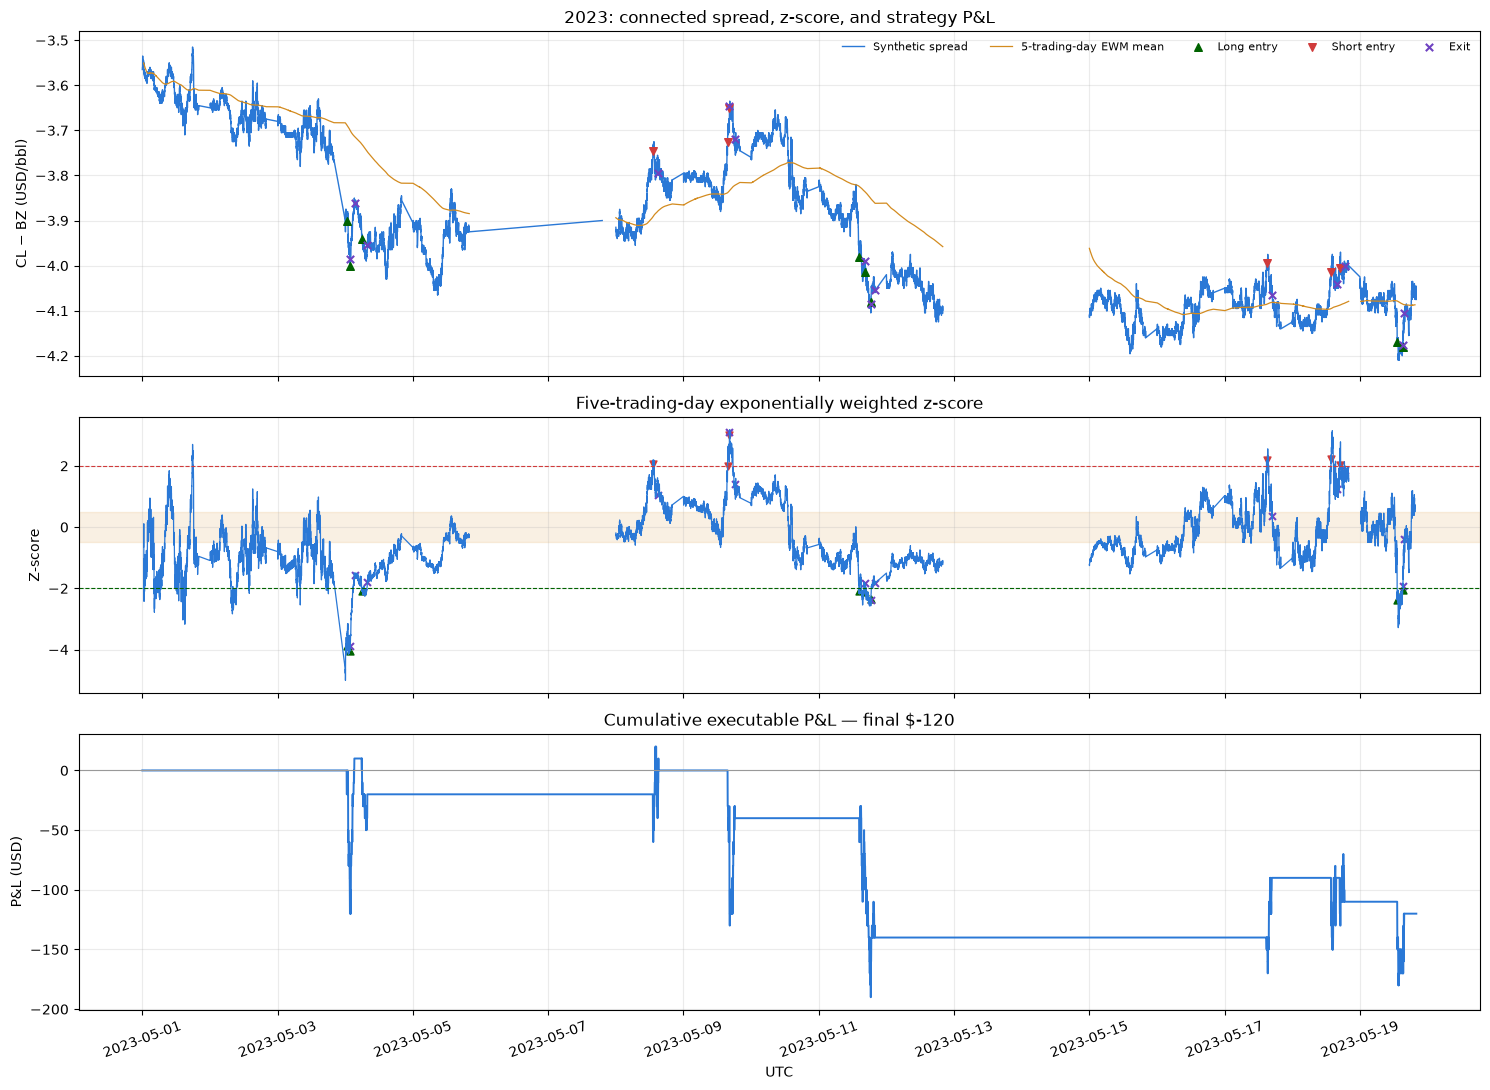

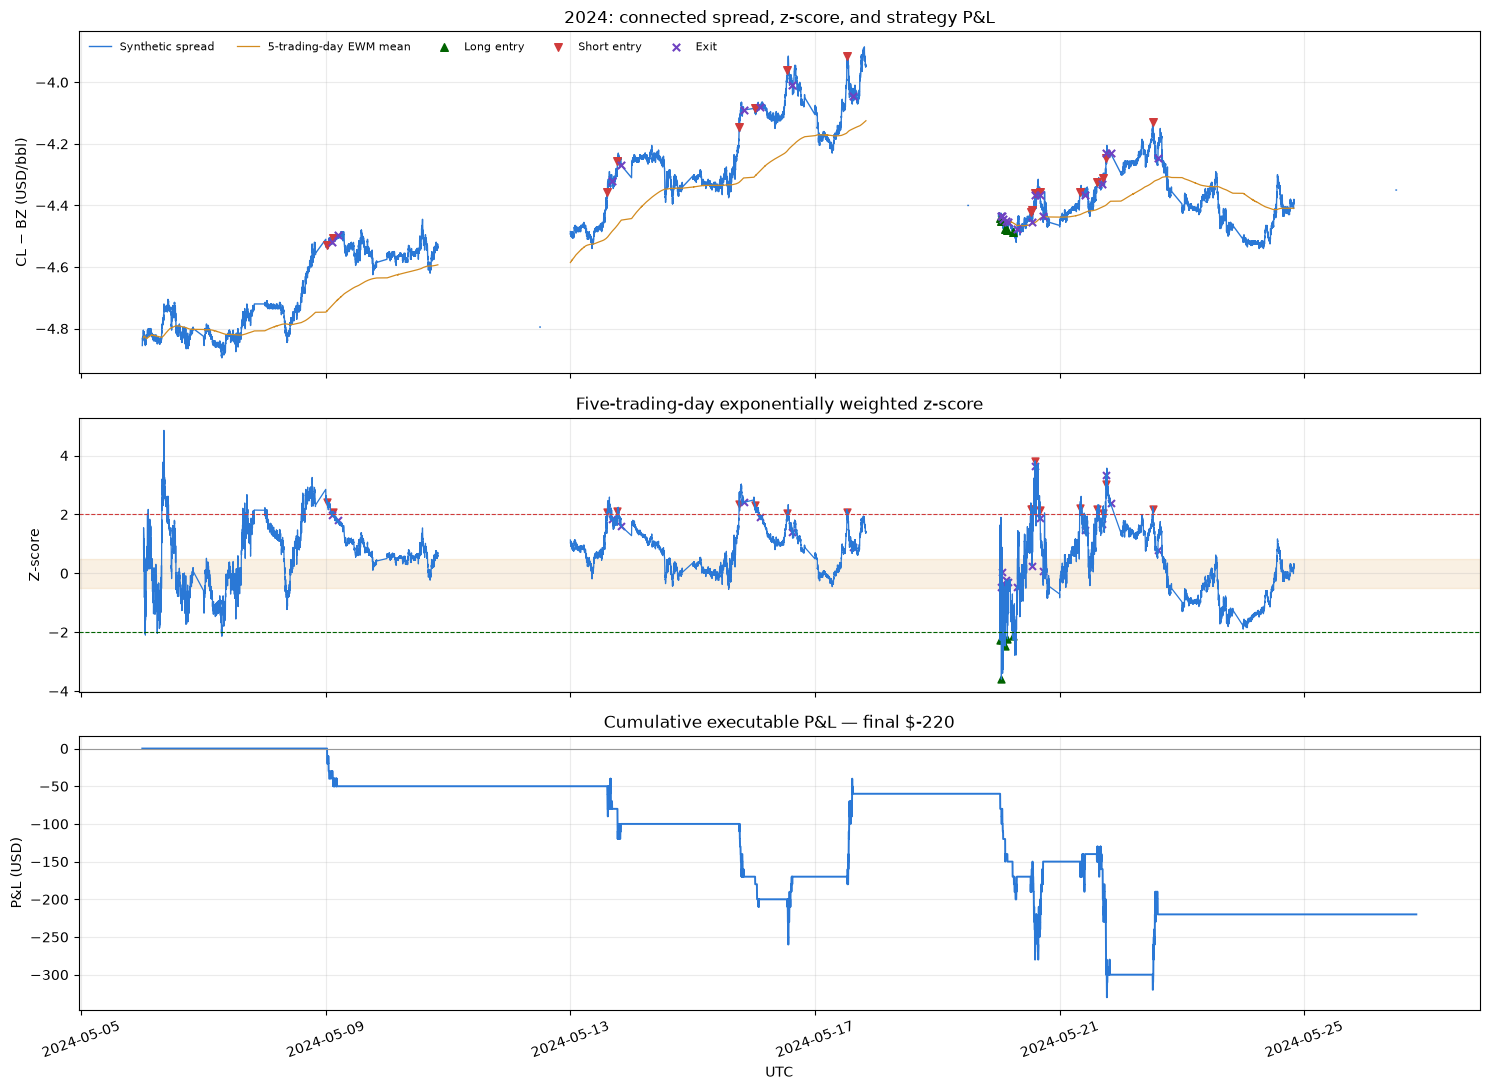

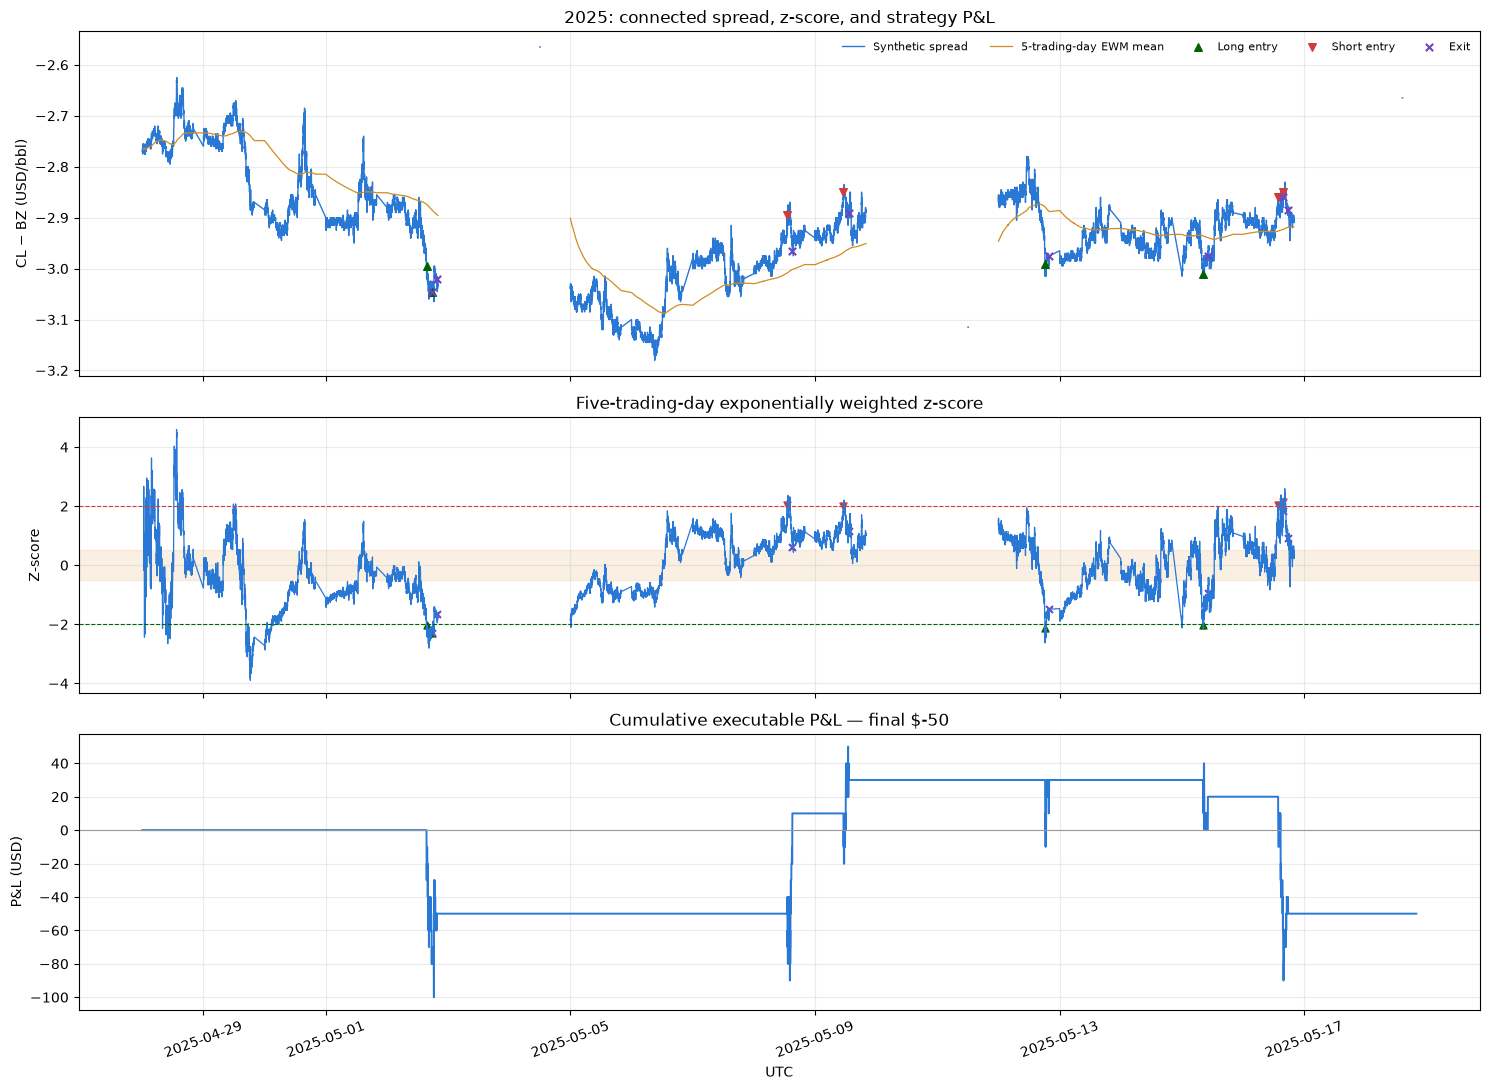

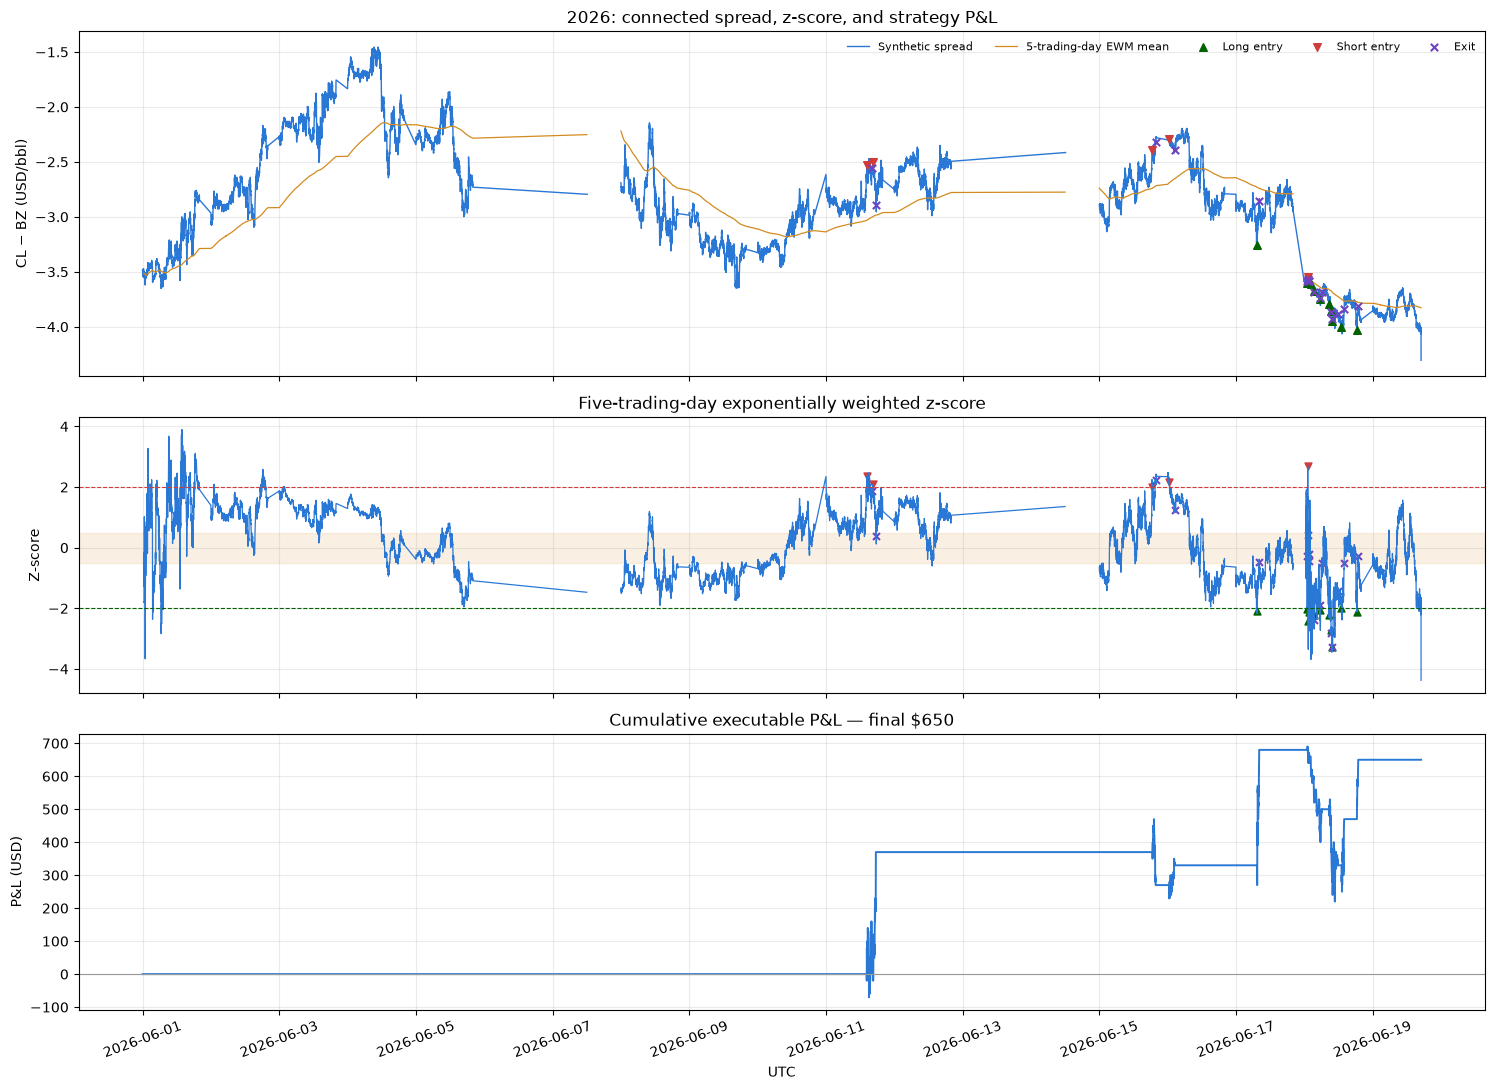

In [8]:
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for year, tracker in backtests.items():
    entries_long = tracker[tracker["long_entry"].fillna(False)]
    entries_short = tracker[tracker["short_entry"].fillna(False)]
    exits = tracker[tracker["exit_flag"].fillna(False)]

    fig, (spread_ax, signal_ax, pnl_ax) = plt.subplots(
        3,
        1,
        figsize=(15, 11),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0, 1.0]},
    )

    spread_ax.plot(tracker.index, tracker["synth_mid"], color="#2a78d6", lw=1.0, label="Synthetic spread")
    spread_ax.plot(tracker.index, tracker["ewm_mean_5td"], color="#d38b1f", lw=0.9, label="5-trading-day EWM mean")
    spread_ax.scatter(entries_long.index, entries_long["synth_mid"], marker="^", color="#006300", s=30, label="Long entry", zorder=3)
    spread_ax.scatter(entries_short.index, entries_short["synth_mid"], marker="v", color="#d03b3b", s=30, label="Short entry", zorder=3)
    spread_ax.scatter(exits.index, exits["synth_mid"], marker="x", color="#6f42c1", s=28, label="Exit", zorder=3)
    spread_ax.set_title(f"{year}: connected spread, z-score, and strategy P&L")
    spread_ax.set_ylabel("CL − BZ (USD/bbl)")
    spread_ax.legend(frameon=False, ncols=5, fontsize=8)
    spread_ax.grid(alpha=0.25)

    signal_ax.plot(tracker.index, tracker["zscore"], color="#2a78d6", lw=0.9)
    signal_ax.axhline(ENTRY_Z, color="#d03b3b", ls="--", lw=0.8)
    signal_ax.axhline(-ENTRY_Z, color="#006300", ls="--", lw=0.8)
    signal_ax.axhspan(-EXIT_Z, EXIT_Z, color="#d38b1f", alpha=0.12, label="Exit band")
    signal_ax.scatter(entries_long.index, entries_long["zscore"], marker="^", color="#006300", s=25)
    signal_ax.scatter(entries_short.index, entries_short["zscore"], marker="v", color="#d03b3b", s=25)
    signal_ax.scatter(exits.index, exits["zscore"], marker="x", color="#6f42c1", s=25)
    signal_ax.set_title("Five-trading-day exponentially weighted z-score")
    signal_ax.set_ylabel("Z-score")
    signal_ax.grid(alpha=0.25)

    pnl_ax.plot(tracker.index, tracker["cum_pnl"], color="#2a78d6", lw=1.4)
    pnl_ax.axhline(0, color="#999999", lw=0.8)
    final_pnl = float(tracker["cum_pnl"].iloc[-1])
    pnl_ax.set_title(f"Cumulative executable P&L — final ${final_pnl:,.0f}")
    pnl_ax.set_ylabel("P&L (USD)")
    pnl_ax.set_xlabel("UTC")
    pnl_ax.grid(alpha=0.25)

    pnl_ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"spread_zscore_pnl_{year}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Export results

In [9]:
year_summary.to_csv(OUTPUT_DIR / "year_summary.csv")
trade_log.to_csv(OUTPUT_DIR / "trade_log.csv", index=False)
trade_log.to_parquet(OUTPUT_DIR / "trade_log.parquet", index=False)
for year, tracker in backtests.items():
    tracker.to_parquet(OUTPUT_DIR / f"backtest_{year}.parquet")

print(f"Saved results to {OUTPUT_DIR}")
print(f"Completed trades: {len(trade_log):,}")

Saved results to _output/ewm_7d_zscore_backtest
Completed trades: 62
